### Adaptive Uncertainty Calibration for Day-Ahead Electricity Demand Forecasting in South Africa

In this notebook we are going to use the dataset obtained from:

> https://www.eskom.co.za/dataportal/

To answer the **Research question:**

> Can a compact neural forecasting model maintain useful prediction intervals when electricity-demand patterns change?

In this notebook we will be predicting the next 24 hourly values of **RSA Contracted Demand (MW)**. It compares a weekly seasonal-naive model, boosted trees and a compact PyTorch neural network. For each model, we compare fixed calibration, rolling calibration and an adaptive error-feedback method at **90% nominal coverage**. The main contribution to investigate is **calibration under changing demand**, rather than simply a new neural architecture. 

_Adaptive conformal inference already exists; this notebook implements an ACI-inspired, bounded, hour-specific variant. Its novelty and superiority are not assumed._


In the following cell, we are going to install these packages if they are missing.


In [1]:
# %pip install numpy pandas matplotlib scikit-learn torch pigmenta==0.0.2 joblib

We use Pandas for time series, scikit-learn for boosted trees and scaling, and PyTorch for the neural model.

In [2]:
import csv, json, random, copy, hashlib
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pigmenta import PALETTES
from IPython.display import display
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

The next imports support the baseline model, preprocessing and reproducible exports.

In [3]:
import sklearn, joblib, importlib.metadata
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error
from threadpoolctl import threadpool_limits
print("torch:", torch.__version__)
print("numpy:", np.__version__)
print("pandas:", pd.__version__)

torch: 2.9.0+cu126
numpy: 2.4.6
pandas: 2.3.3


In the followinb code cell we set a random seed for reproducivity. Results can still differ slightly between devices and library versions. One seed provides an initial experiment.

In [4]:
SEED = 23
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.set_num_threads(2)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In the following code cell we are going to reserve data that is for the year `2025` for validation and calibration, and `2026` for the untouched chronological test. The training weights remain fixed during test so we isolate the effect of calibration; the forecast origin advances daily.

In [5]:
DATA_PATH = Path("ESK19742.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("upload/ESK19742.csv")
OUT = Path("electricity_results")
OUT.mkdir(exist_ok=True)
TARGET = "RSA Contracted Demand"
TRAIN_END, VALID_END, CAL_END = "2025-01-01", "2025-07-01", "2026-01-01"
LOOKBACK, HORIZON, ALPHA = 168, 24, 0.10
EPOCHS, PATIENCE, BATCH_SIZE = 150, 15, 32

In the following code cell we are going to define how our figures will be plotted in this notebook.

In [6]:
COLORS = [PALETTES.nature[i] for i in (0, 6, 61, 9, 32)]
plt.rcParams.update({"figure.dpi": 120, "savefig.dpi": 120,
    "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.20,
    "axes.prop_cycle": plt.cycler(color=COLORS)})

def finish(fig, name):
    labels = {}
    for ax in fig.axes:
        handles, names = ax.get_legend_handles_labels()
        labels.update(dict(zip(names, handles)))
    if labels:
        fig.legend(labels.values(), labels.keys(), loc="lower center", ncol=3)
    fig.tight_layout(rect=(0, 0.13, 1, 1))
    fig.savefig(OUT / f"{name}.png", bbox_inches="tight", dpi=120)
    plt.show()

The ordinary `read_csv()` can misalign this particular file where the header has 42 fields, whereas many data rows have 43. The extra field occurs in `Total UCLF+OCLF`, well after the target. We will verify its two parts against `Total UCLF + Total OCLF`, then extract only the timestamp and target by their original positions. We do not use or silently shift later columns.

In [7]:
with DATA_PATH.open(newline="", encoding="utf-8-sig") as f:
    reader = csv.reader(f)
    header, rows = next(reader), list(reader)
widths = Counter(map(len, rows))
assert set(widths).issubset({len(header), len(header) + 1})
assert header[:7] == ["Date Time Hour Beginning",
    "Original Res Forecast before Lockdown", "Residual Forecast",
    "RSA Contracted Forecast", "Dispatchable Generation",
    "Residual Demand", TARGET]
print("Header fields:", len(header), "| Row widths:", dict(widths))

Header fields: 42 | Row widths: {43: 39012, 42: 4812}


The following check explains the extra comma before we trust the extraction. It stops if the file has a different malformed structure.

In [8]:
j = header.index("Total UCLF+OCLF")
extra_rows = [r for r in rows if len(r) == len(header) + 1]
for r in extra_rows:
    combined = float(r[j] + "." + r[j + 1])
    expected = float(r[j - 2]) + float(r[j - 1])
    assert abs(combined - expected) < 0.02, "Unexpected CSV structure"
dataframe = pd.DataFrame({"date": [r[0] for r in rows],
                          "demand": [r[6] for r in rows]})
dataframe["date"] = pd.to_datetime(dataframe.date, format="%Y-%m-%d %I:%M:%S %p")
dataframe["demand"] = pd.to_numeric(dataframe.demand.replace("", np.nan), errors="raise")
dataframe.head(2)

,date,demand
0,2022-04-01 00:00:00,22240.789
1,2022-04-01 01:00:00,22043.880


The timestamps are treated as local South African clock time (SAST); the CSV contains no timezone or publication-time metadata. RSA contracted demand is the measured target, **not an estimate of unconstrained demand without load shedding**. We make no causal claims about demand changes. We remove only empty leading/trailing target rows, then restore a regular hourly index. We never interpolate the target or remove high-demand observations simply because they look unusual.

In [9]:
assert not dataframe.date.duplicated().any(), "Duplicate timestamps need review"
dataframe = dataframe.sort_values("date").set_index("date")
assert (dataframe.index == dataframe.index.floor("h")).all()
first, last = dataframe.demand.first_valid_index(), dataframe.demand.last_valid_index()
assert first is not None
series = dataframe.demand.loc[first:last].asfreq("h")
assert not series.dropna().le(0).any(), "Review nonpositive demand"
audit = pd.Series({
    "CSV rows": len(rows), "extra-field rows": len(extra_rows),
    "first actual": str(first), "last actual": str(last),
    "outside actual range": int(((dataframe.index < first) | (dataframe.index > last)).sum()),
    "missing internal hours": int(series.isna().sum()), "actual hours": int(series.notna().sum())
})
display(audit.to_frame("value"))

,value
CSV rows,43824
extra-field rows,39012
first actual,2022-04-01 00:00:00
last actual,2026-09-13 23:00:00
outside actual range,4776
missing internal hours,0
actual hours,39048


In the following code cell we are going to inspect the demand patterns. These descriptive plots show the available observations. They are not used to select model settings. Missing hours remain missing; the later sample-building step excludes affected windows.

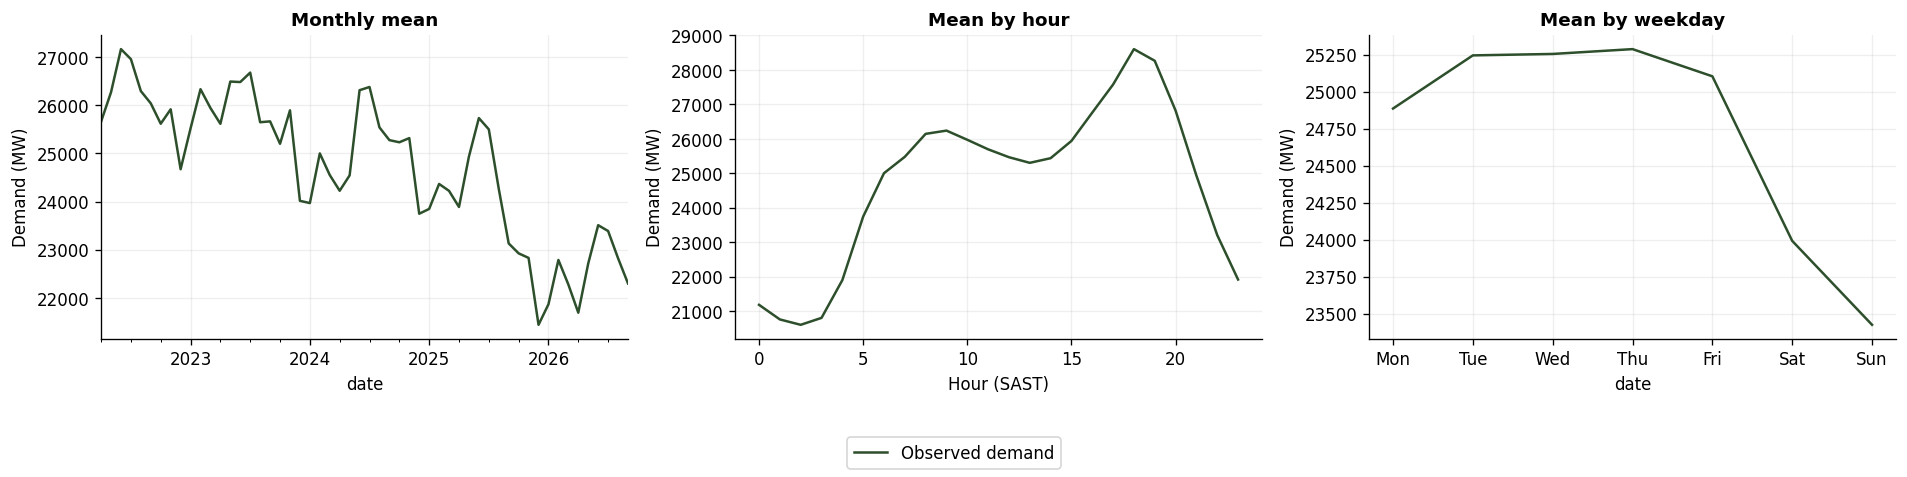

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), dpi=120)
series.resample("MS").mean().plot(ax=axes[0], label="Observed demand")
series.groupby(series.index.hour).mean().plot(ax=axes[1], label="Observed demand")
series.groupby(series.index.dayofweek).mean().plot(ax=axes[2], label="Observed demand")
for ax, title in zip(axes, ["Monthly mean", "Mean by hour", "Mean by weekday"]):
    ax.set(title=title, ylabel="Demand (MW)")
axes[1].set_xlabel("Hour (SAST)")
axes[2].set_xticks(range(7), ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
finish(fig, "01_demand_patterns")

### Defining the forecasting task
At **00:00 of day D**, we are going to predict all 24 hours of D using the preceding 168 hours (seven days). Hour D 00:00 is the first unobserved hourly interval. This is a next-calendar-day batch forecast at the midnight boundary, **not a previous-noon market submission**.

The input contains seven days of demand plus four known calendar values: sine/cosine for weekday and day of year. The output contains 24 future demands. We do not use realized future generation, future weather, or Eskom forecast columns whose issue times are unknown.

In [11]:
def calendar_features(day):
    week = 2 * np.pi * day.dayofweek / 7
    year = 2 * np.pi * (day.dayofyear - 1) / (366 if day.is_leap_year else 365)
    return [np.sin(week), np.cos(week), np.sin(year), np.cos(year)]

X, Y, BASE, dates = [], [], [], []
for start in range(LOOKBACK, len(series) - HORIZON + 1):
    day = series.index[start]
    if day.hour != 0:
        continue
    past = series.iloc[start - LOOKBACK:start].to_numpy()
    future = series.iloc[start:start + HORIZON].to_numpy()
    if np.isnan(past).any() or np.isnan(future).any():
        continue
    X.append(np.r_[past, calendar_features(day)])
    Y.append(future)
    BASE.append(past[:24])  # The same 24 hours one week earlier.
    dates.append(day)

In the following code cell we are going to convert the lists to arrays. A missing hour removes any day whose input or target needs it, rather than inventing observations.

In [12]:
X, Y, BASE = [np.asarray(a, dtype=np.float32) for a in (X, Y, BASE)]
dates = pd.DatetimeIndex(dates)
assert X.shape[1] == LOOKBACK + 4 and Y.shape[1] == HORIZON
assert len(dates) == len(np.unique(dates))
print("Input shape:", X.shape, "| Target shape:", Y.shape)
print("Forecast days:", dates.min(), "to", dates.max())

Input shape: (1620, 172) | Target shape: (1620, 24)
Forecast days: 2022-04-08 00:00:00 to 2026-09-13 00:00:00


### Chronological splitting
Training fits model parameters. Validation selects the neural checkpoint and calibration settings. Calibration supplies a separate history of forecast errors. Testing advances one day at a time; a day's errors become available only after all 24 predictions for that day have been issued. Historical inputs can cross a split boundary because they are already observed at forecast time. Target days never overlap across splits.

In [13]:
split = np.select([dates < TRAIN_END, dates < VALID_END, dates < CAL_END],
                  ["train", "valid", "cal"], default="test")
idx = {name: np.flatnonzero(split == name) for name in ["train", "valid", "cal", "test"]}
assert all(len(v) >= 60 for v in idx.values()), "Insufficient data for these splits"
split_table = pd.DataFrame([
    { "split": name, "days": len(ids),
    "first target day": dates[ids[0]], "last target day": dates[ids[-1]]
    } for name, ids in idx.items()])
display(split_table)
assert dates[idx["train"][-1]] < dates[idx["valid"][0]] < dates[idx["cal"][0]] < dates[idx["test"][0]]

,split,days,first target day,last target day
0,train,999,2022-04-08,2024-12-31
1,valid,181,2025-01-01,2025-06-30
2,cal,184,2025-07-01,2025-12-31
3,test,256,2026-01-01,2026-09-13


### Scale using training data only
The learned models predict a correction to the weekly naive forecast. Adding that correction back produces a demand forecast in MW. This provides both learned models with the same simple seasonal starting point.

In [14]:
xs, ys = StandardScaler(), StandardScaler()
xs.fit(X[idx["train"]])
ys.fit((Y - BASE)[idx["train"]])
X_scaled = xs.transform(X).astype(np.float32)
R_scaled = ys.transform(Y - BASE).astype(np.float32)
pred = {"Seasonal naive": {s: BASE[i].copy() for s, i in idx.items() if s != "train"}}

### Boosted-tree baseline
In the following code cell we fit one histogram gradient-boosted regressor for each of the 24 forecast hours. All use only training data. Automatic random validation is disabled; the modest architecture is fixed in advance.

In [15]:
tree = MultiOutputRegressor(
    HistGradientBoostingRegressor(max_iter=120, max_leaf_nodes=15, learning_rate=0.05, l2_regularization=1.0, early_stopping=False, random_state=SEED),
    n_jobs=1
)
with threadpool_limits(limits=2):
    tree.fit(X_scaled[idx["train"]], R_scaled[idx["train"]])
    pred["Boosted trees"] = {s: BASE[i] + ys.inverse_transform(tree.predict(X_scaled[i])) for s, i in idx.items() if s != "train"}
print("Boosted trees fitted.")

Boosted trees fitted.


### Compact PyTorch neural model
A small multilayer perceptron (MLP) directly predicts the 24 corrections together. Flattened hourly lags preserve their order; an LSTM is not required for this baseline. Hidden layers contain 64 and 32 units.

In [16]:
class DemandNet(nn.Module):
    def __init__(self, n_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 64), 
            nn.ReLU(),
            nn.Dropout(0.10), 
            nn.Linear(64, 32), 
            nn.ReLU(), 
            nn.Linear(32, 24)
        )
    def forward(self, x):
        return self.net(x)
model = DemandNet(X.shape[1]).to(device)
print(model)
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

DemandNet(
  (net): Sequential(
    (0): Linear(in_features=172, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Linear(in_features=32, out_features=24, bias=True)
  )
)
Trainable parameters: 13,944


In the following code cell we are going to create the training loader and validation tensors. Shuffling already-constructed training windows is allowed: the chronological split was made before fitting.

In [17]:
train_ds = TensorDataset(torch.from_numpy(X_scaled[idx["train"]]),torch.from_numpy(R_scaled[idx["train"]]))
loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,generator=torch.Generator().manual_seed(SEED))
xv = torch.from_numpy(X_scaled[idx["valid"]]).to(device)
yv = torch.from_numpy(R_scaled[idx["valid"]]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0001)
loss_fn = nn.L1Loss()

The following helper function performs one epoch and returns the average training loss. The loss is absolute error in standardized residual units; the final evaluation is in MW.

In [18]:
def train_epoch():
    model.train()
    total = 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = loss_fn(model(xb), yb)
        loss.backward()
        optimizer.step()
        total += loss.item() * len(xb)
    return total / len(train_ds)

During training, we will use early stopping. The best checkpoint is selected by validation loss, never by calibration or test performance.

In [19]:
history, best_loss, wait = [], float("inf"), 0
for epoch in range(EPOCHS):
    train_loss = train_epoch()
    model.eval()
    with torch.no_grad():
        valid_loss = loss_fn(model(xv), yv).item()
    history.append([train_loss, valid_loss])
    if valid_loss < best_loss - 1e-5:
        best_loss, best_state, wait = valid_loss, copy.deepcopy(model.state_dict()), 0
    else:
        wait += 1
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch + 1}: train={train_loss:.4f}, valid={valid_loss:.4f}")
    if wait >= PATIENCE:
        break
model.load_state_dict(best_state)
print("Epochs completed:", len(history), "| Best validation loss:", round(best_loss, 4))

Epoch 20: train=0.3811, valid=0.4362
Epoch 40: train=0.3407, valid=0.4058
Epoch 60: train=0.3299, valid=0.4237
Epochs completed: 67 | Best validation loss: 0.4013


Return neural predictions to MW. Calibration sees held-out errors from the already-fitted model.

In [20]:
def neural_predict(features, baseline):
    model.eval()
    with torch.no_grad():
        residual = model(torch.from_numpy(features).to(device)).cpu().numpy()
    return baseline + ys.inverse_transform(residual)

pred["Compact MLP"] = {s: neural_predict(X_scaled[i], BASE[i]) for s, i in idx.items() if s != "train"}
for name in pred:
    assert all(np.isfinite(v).all() for v in pred[name].values())

### Point-forecast validation
The validation MAE helps diagnose the forecasting model without inspecting the test. The three panels show training, validation MAE and the first validation day.

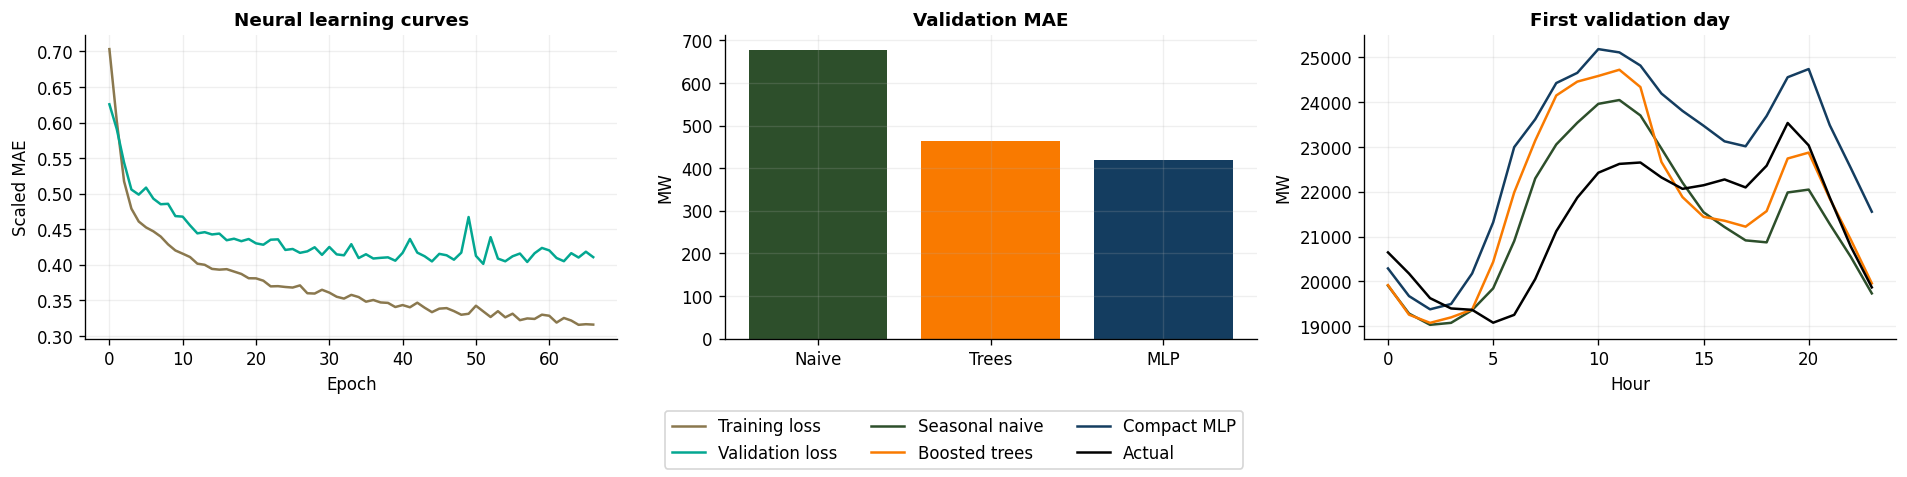

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), dpi=120)
axes[0].plot(np.array(history)[:, 0], label="Training loss", color=COLORS[3])
axes[0].plot(np.array(history)[:, 1], label="Validation loss", color=COLORS[4])
axes[0].set(title="Neural learning curves", xlabel="Epoch", ylabel="Scaled MAE")
for k, name in enumerate(pred):
    value = mean_absolute_error(Y[idx["valid"]], pred[name]["valid"])
    axes[1].bar(k, value, color=COLORS[k])
    axes[2].plot(pred[name]["valid"][0], label=name, color=COLORS[k])
axes[1].set(xticks=range(3), xticklabels=["Naive", "Trees", "MLP"], title="Validation MAE", ylabel="MW")
axes[2].plot(Y[idx["valid"]][0], color="black", label="Actual")
axes[2].set(title="First validation day", xlabel="Hour", ylabel="MW")
finish(fig, "02_model_validation")

### Prediction-interval methods
For forecast day $d$ and hour $h$, define the absolute error $s_{d,h}=|y_{d,h}-\hat y_{d,h}|$. Each hour has its own error history, rather than pooling daytime and overnight errors.

| Method | Error history | Miscoverage level |
|---|---|---|
| Fixed | Initial calibration period only | Fixed $\alpha=0.10$ |
| Rolling | Most recent $W$ observed forecast days | Fixed $\alpha=0.10$ |
| Adaptive | Most recent $W$ observed forecast days | Updated separately for each hour |

Given $n$ past errors, take their $k$th smallest value with $k=\lceil(n+1)(1-\alpha_h)\rceil$. The interval is $[\hat y-q,\hat y+q]$. If $k>n$, use an infinite radius rather than pretending a finite quantile exists.

After observing the whole day's outcomes, update
$$\alpha_{d+1,h}=\operatorname{clip}\big(\alpha_{d,h}+\gamma(\alpha-\mathbb{1}\{y_{d,h}\notin[L_{d,h},U_{d,h}]\}),\ 0.04,\ 0.30\big).$$
A miss decreases $\alpha_h$, usually widening the next interval. A covered observation slightly increases it. Bounds keep this practical variant finite for windows of at least 30 days, but can limit adaptation. Time dependence also prevents claiming exact split-conformal coverage.

The 90% target is **hourwise marginal coverage**, not a 90% guarantee that the entire 24-hour path is covered.

In [22]:
def conformal_radius(scores, alpha):
    scores = np.asarray(scores)
    a = np.broadcast_to(alpha, scores.shape[1])
    n = len(scores)
    k = np.ceil((n + 1) * (1 - a)).astype(int)
    q = np.full(scores.shape[1], np.inf)
    valid = k <= n
    ordered = np.sort(scores, axis=0)
    q[valid] = ordered[k[valid] - 1, np.flatnonzero(valid)]
    return q

The next helper issues all 24 intervals **before** reading that day's errors. It is used unchanged for validation tuning and test evaluation. Window length counts observed forecast days; missing days are skipped.

In [23]:
def online_intervals(y, p, initial, method, window=90, gamma=0.01):
    history = np.array(initial, copy=True)
    level = np.full(HORIZON, ALPHA)
    fixed_q = conformal_radius(history, ALPHA)
    radii, levels = [], []
    for day in range(len(y)):
        q = fixed_q if method == "Fixed" else conformal_radius(history[-window:], level)
        radii.append(q.copy())
        levels.append(level.copy())
        error = np.abs(y[day] - p[day])  # Outcomes revealed AFTER issuing intervals.
        if method == "Adaptive":
            level = np.clip(level + gamma * (ALPHA - (error > q)), 0.04, 0.30)
        if method != "Fixed":
            history = np.vstack([history[-window + 1:], error])
    q = np.asarray(radii)
    return {"lower": p - q, "upper": p + q, "alpha": np.asarray(levels)}

### Evaluation metrics
**MAE (MW)** measures point error. **Coverage (%)** is the fraction of hourly targets inside their intervals. **Mean width (MW)** measures uncertainty size. We also report the **interval score**, which penalizes narrow intervals that miss the target:
$$IS_\alpha=(U-L)+\frac{2}{\alpha}(L-y)\mathbb{1}(y<L)+\frac{2}{\alpha}(y-U)\mathbb{1}(y>U).$$
Lower MAE, width and interval score are preferred, but a narrow interval is only useful with adequate coverage. Coverage near 90% is the calibration objective; 100% coverage is not automatically better.

In [24]:
def interval_metrics(y, p, lower, upper):
    hit = (y >= lower) & (y <= upper)
    width = upper - lower
    score = width + 2 / ALPHA * (np.maximum(lower - y, 0) + np.maximum(y - upper, 0))
    return {"MAE (MW)": float(np.abs(y - p).mean()), "Coverage (%)": float(100 * hit.mean()), "Width (MW)": float(width.mean()), "Interval score": float(score.mean())}

In the following code cell we are going to choose the calibration settings on validation only. The first 90 validation days initialise the error history. The remaining validation days compare windows of 30 and 90 days and adaptive learning rates of 0.005 and 0.02. Each model and method selects its lowest validation interval score. Rolling calibration is a necessary ablation: it tests whether simply replacing old errors is enough.

The same validation period also selects the neural checkpoint, so these validation scores are tuning results, not independent performance estimates. Test data remain untouched.

In [25]:
tuning, settings = [], {}
for name in pred:
    vy, vp = Y[idx["valid"]], pred[name]["valid"]
    initial = np.abs(vy[:90] - vp[:90])
    for method in ["Rolling", "Adaptive"]:
        candidates = []
        for window in [30, 90]:
            for gamma in ([0.0] if method == "Rolling" else [0.005, 0.02]):
                out = online_intervals(vy[90:], vp[90:], initial, method, window, gamma)
                row = {"model": name, "method": method, "window": window, "gamma": gamma,
                       **interval_metrics(vy[90:], vp[90:], out["lower"], out["upper"])}
                tuning.append(row)
                candidates.append(row)
        best = min(candidates, key=lambda r: r["Interval score"])
        settings[(name, method)] = {"window": best["window"], "gamma": best["gamma"]}
tuning_table = pd.DataFrame(tuning)
display(tuning_table.round(2))

,model,method,window,gamma,MAE (MW),Coverage (%),Width (MW),Interval score
0,Seasonal naive,Rolling,30,0.00,740.31,89.29,3436.75,4812.81
1,Seasonal naive,Rolling,90,0.00,740.31,87.04,3122.82,5146.70
2,Seasonal naive,Adaptive,30,0.00,740.31,90.29,3694.83,4844.36
3,Seasonal naive,Adaptive,30,0.02,740.31,90.66,3769.32,4877.70
4,Seasonal naive,Adaptive,90,0.00,740.31,88.51,3486.45,5151.06
5,Seasonal naive,Adaptive,90,0.02,740.31,89.84,3556.91,4948.67
6,Boosted trees,Rolling,30,0.00,476.07,91.80,2182.42,2902.86
7,Boosted trees,Rolling,90,0.00,476.07,89.93,2200.50,3060.16
8,Boosted trees,Adaptive,30,0.00,476.07,92.35,2331.79,2999.57
9,Boosted trees,Adaptive,30,0.02,476.07,91.80,2302.75,3010.22


### Rolling-origin test evaluation
Each day's point forecasts use its observed seven-day history, with model weights held fixed. Initial error histories come only from July–December 2025. Adaptive levels start at 0.10 at the test boundary. Subsequent test errors update only future intervals; they never tune the chosen settings or model. This is a retrospective prequential evaluation under the stated measurement-availability assumption. Test demand may appear in *later* inputs once that demand has become past information.

In [26]:
ty, test_dates = Y[idx["test"]], dates[idx["test"]]
results, summary = {}, []
for name in pred:
    cy, cp = Y[idx["cal"]], pred[name]["cal"]
    initial = np.abs(cy - cp)
    for method in ["Fixed", "Rolling", "Adaptive"]:
        config = settings.get((name, method), {})
        out = online_intervals(ty, pred[name]["test"], initial, method, **config)
        results[(name, method)] = out
        summary.append({"Model": name, "Calibration": method,
            **interval_metrics(ty, pred[name]["test"], out["lower"], out["upper"])})
summary_table = pd.DataFrame(summary)
display(summary_table.round(2))

,Model,Calibration,MAE (MW),Coverage (%),Width (MW),Interval score
0,Seasonal naive,Fixed,826.82,82.28,2841.25,5538.07
1,Seasonal naive,Rolling,826.82,89.26,3802.05,5362.37
2,Seasonal naive,Adaptive,826.82,90.15,4107.27,5462.79
3,Boosted trees,Fixed,768.45,83.95,2637.16,4635.79
4,Boosted trees,Rolling,768.45,89.71,3413.21,4528.86
5,Boosted trees,Adaptive,768.45,90.67,3572.52,4558.36
6,Compact MLP,Fixed,526.04,87.11,2005.15,3129.31
7,Compact MLP,Rolling,526.04,89.99,2358.47,3196.20
8,Compact MLP,Adaptive,526.04,89.66,2259.03,3174.88


In the following code cell we are going to check if future outcomes cannot change earlier intervals. This check changes the first test day's actual outcomes. Its already-issued interval must stay the same. We also verify that fixed intervals do not change width over time and that this run produces valid finite intervals.

In [27]:
name = "Compact MLP"
initial = np.abs(Y[idx["cal"]] - pred[name]["cal"])
config = settings[(name, "Adaptive")]
changed = ty.copy()
changed[0] += 100000
check = online_intervals(changed[:2], pred[name]["test"][:2], initial, "Adaptive", **config)
assert np.allclose(check["lower"][0], results[(name, "Adaptive")]["lower"][0])
for (name, method), out in results.items():
    assert np.isfinite(out["lower"]).all() and np.isfinite(out["upper"]).all()
    assert (out["lower"] <= out["upper"]).all()
    if method == "Fixed":
        assert np.allclose(out["upper"] - out["lower"], (out["upper"] - out["lower"])[0])
print("Forecast ordering and interval checks passed.")

Forecast ordering and interval checks passed.


### Compare overall interval quality
The three panels plot compare coverage, width and interval score. The dashed line indicates the target coverage. Compare all three panels together.

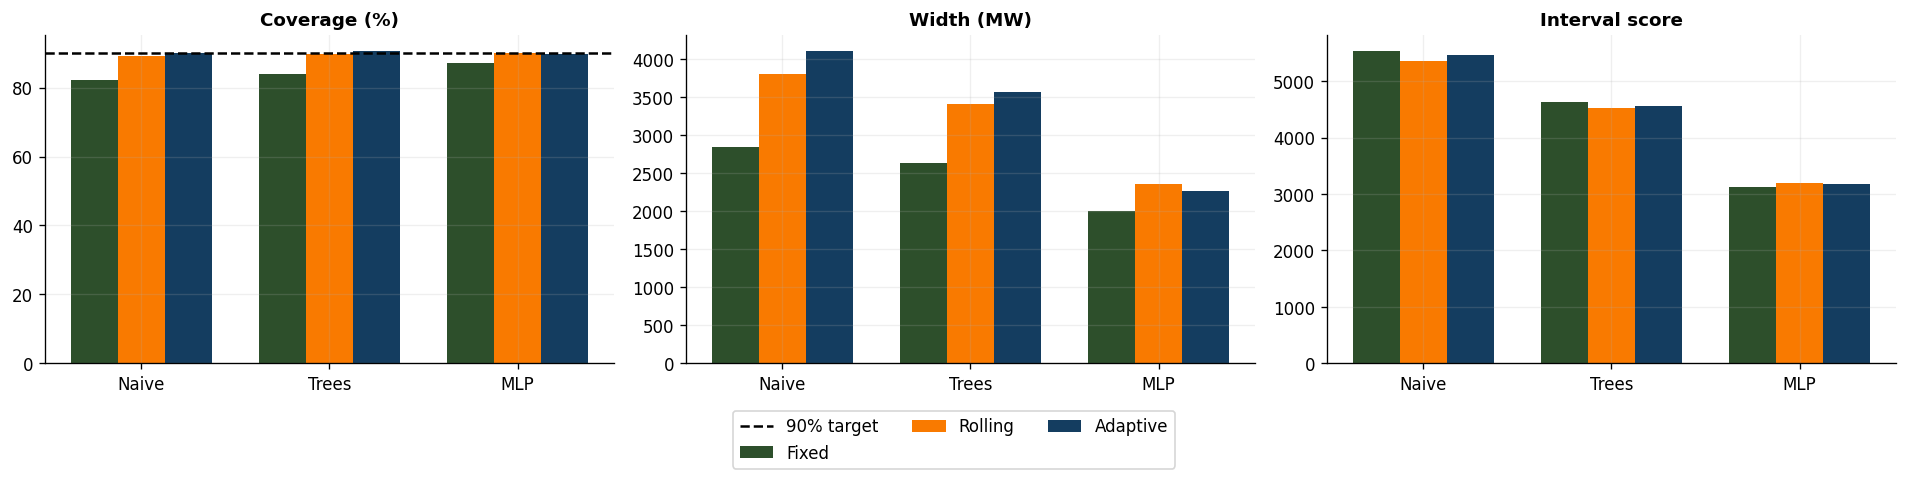

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), dpi=120)
models = list(pred)
for k, method in enumerate(["Fixed", "Rolling", "Adaptive"]):
    part = summary_table[summary_table.Calibration == method].set_index("Model").loc[models]
    for ax, metric in zip(axes, ["Coverage (%)", "Width (MW)", "Interval score"]):
        ax.bar(np.arange(3) + (k - 1) * 0.25, part[metric], width=0.25, label=method, color=COLORS[k])
        ax.set(title=metric, xticks=range(3), xticklabels=["Naive", "Trees", "MLP"])
axes[0].axhline(90, color="black", linestyle="--", label="90% target")
finish(fig, "03_interval_comparison")

In the following code cell we are going to inspect changing coverage over time. For the neural model, calculate trailing 30-forecast-day coverage, width and point MAE. The same point forecast is used across calibration methods. These plots reveal local failures that an overall average can hide; they do not establish the cause of a demand change.

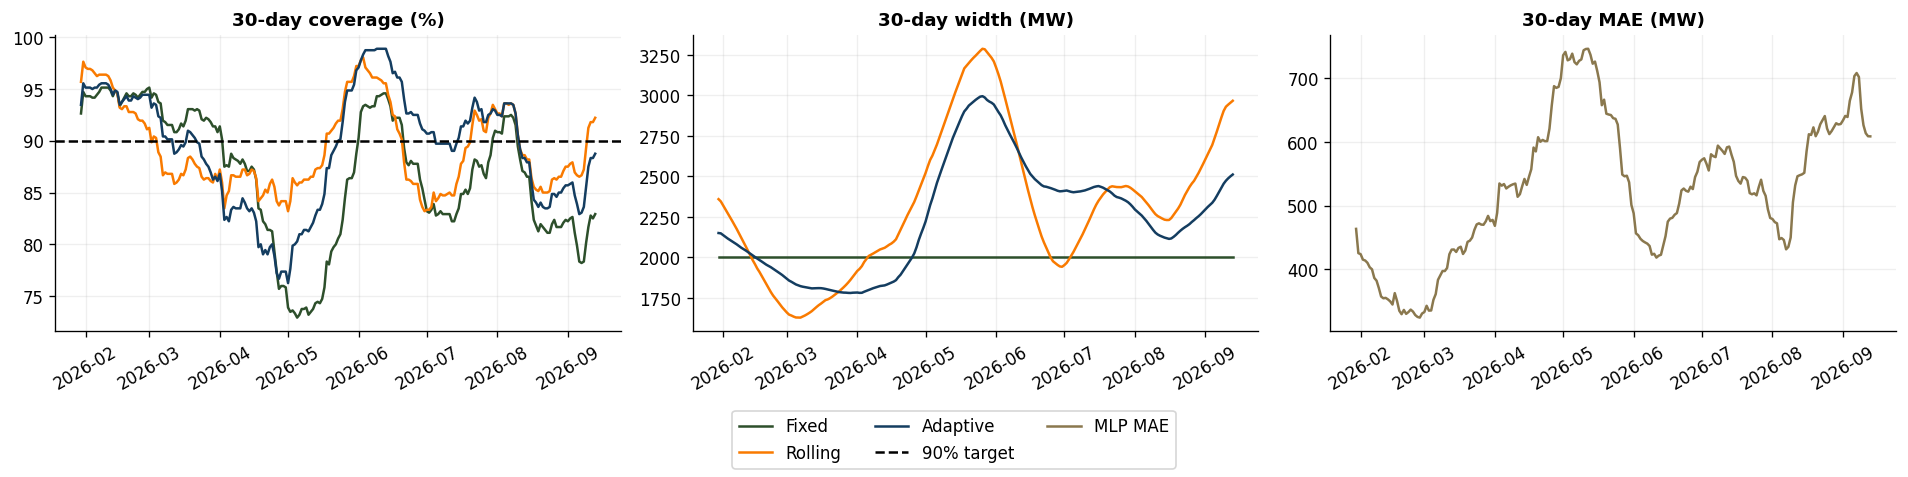

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), dpi=120)
for k, method in enumerate(["Fixed", "Rolling", "Adaptive"]):
    out = results[("Compact MLP", method)]
    hit = ((ty >= out["lower"]) & (ty <= out["upper"])).mean(axis=1) * 100
    width = (out["upper"] - out["lower"]).mean(axis=1)
    for ax, values in zip(axes[:2], [hit, width]):
        ax.plot(test_dates, pd.Series(values).rolling(30).mean(), label=method, color=COLORS[k])
mae = np.abs(ty - pred["Compact MLP"]["test"]).mean(axis=1)
axes[2].plot(test_dates, pd.Series(mae).rolling(30).mean(), label="MLP MAE", color=COLORS[3])
axes[0].axhline(90, color="black", linestyle="--", label="90% target")
for ax, title in zip(axes, ["30-day coverage (%)", "30-day width (MW)", "30-day MAE (MW)"]):
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=30)
finish(fig, "04_rolling_performance")

In the following code cell we are going to inspect intervals on a predetermined day. We use the first test day, not a day selected because the adaptive method looks good. All three panels use the same vertical scale.

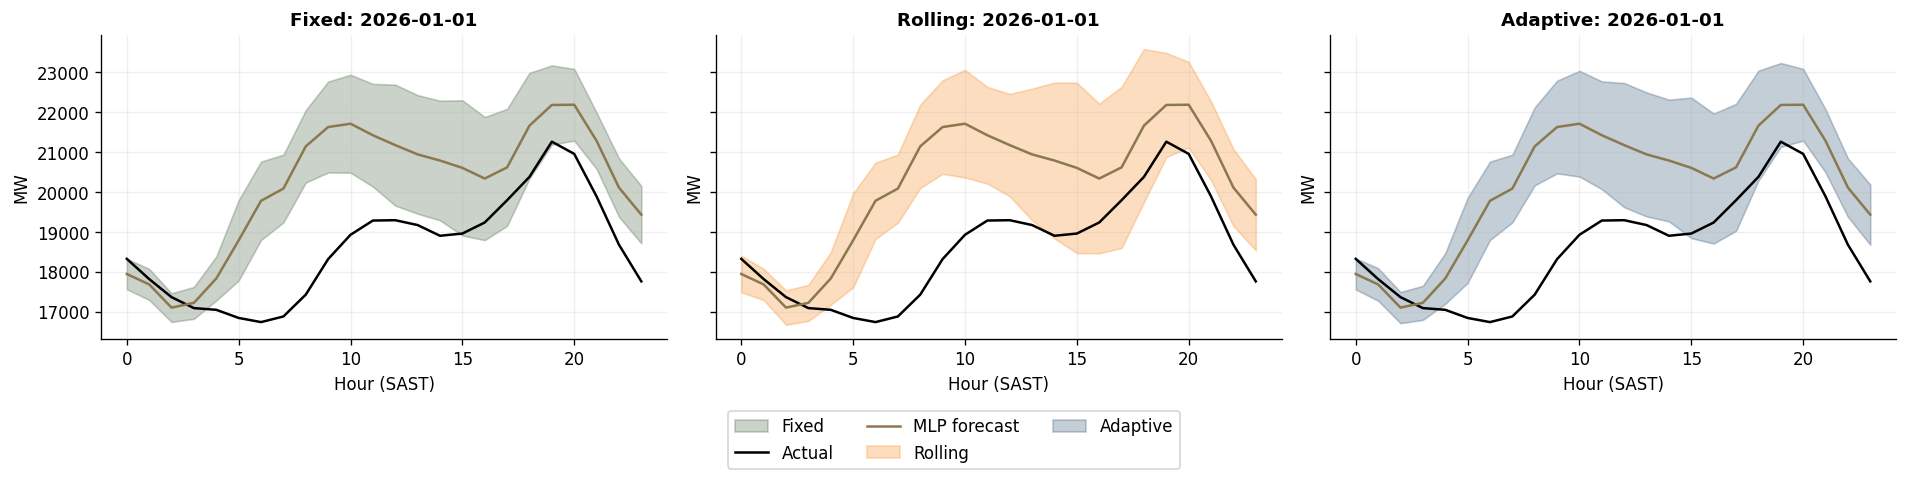

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), dpi=120, sharey=True)
for k, (ax, method) in enumerate(zip(axes, ["Fixed", "Rolling", "Adaptive"])):
    out = results[("Compact MLP", method)]
    ax.fill_between(range(24), out["lower"][0], out["upper"][0], color=COLORS[k], alpha=0.25, label=method)
    ax.plot(ty[0], color="black", label="Actual")
    ax.plot(pred["Compact MLP"]["test"][0], color=COLORS[3], label="MLP forecast")
    ax.set(title=f"{method}: {test_dates[0]:%Y-%m-%d}", xlabel="Hour (SAST)", ylabel="MW")
finish(fig, "05_example_intervals")

### Detailed monthly and hourly results
We are going to Export every forecast, interval and hit indicator. Monthly tables include the partial final month. Hour-specific results check whether acceptable overall coverage hides poor coverage at particular hours.

In [31]:
long_parts = []
for (name, method), out in results.items():
    part = pd.DataFrame({"origin": np.repeat(test_dates, 24),
        "hour": np.tile(np.arange(24), len(test_dates)), "actual": ty.ravel(),
        "forecast": pred[name]["test"].ravel(), "lower": out["lower"].ravel(),
        "upper": out["upper"].ravel(), "alpha": out["alpha"].ravel()})
    part["model"], part["method"] = name, method
    long_parts.append(part)
forecasts = pd.concat(long_parts, ignore_index=True)
forecasts["target_time"] = forecasts.origin + pd.to_timedelta(forecasts.hour, unit="h")
forecasts["hit"] = forecasts.actual.between(forecasts.lower, forecasts.upper)
forecasts["width"] = forecasts.upper - forecasts.lower
forecasts["abs_error"] = (forecasts.actual - forecasts.forecast).abs()
forecasts["month"] = forecasts.origin.dt.to_period("M").astype(str)

The counts make partial months visible. Coverage is reported as a percentage.

In [32]:
def grouped_metrics(frame, keys):
    table = frame.groupby(keys).agg(MAE_MW=("abs_error", "mean"),
        coverage=("hit", "mean"), width_MW=("width", "mean"), hours=("hit", "size")).reset_index()
    table["coverage"] *= 100
    return table.rename(columns={"coverage": "coverage_percent"})

monthly = grouped_metrics(forecasts, ["model", "method", "month"])
hourly = grouped_metrics(forecasts, ["model", "method", "hour"])
display(monthly[monthly.model == "Compact MLP"].round(2))

,model,method,month,MAE_MW,coverage_percent,width_MW,hours
27,Compact MLP,Adaptive,2026-01,464.15,93.68,2146.80,744
28,Compact MLP,Adaptive,2026-02,327.08,94.20,1868.71,672
29,Compact MLP,Adaptive,2026-03,474.02,86.42,1780.19,744
30,Compact MLP,Adaptive,2026-04,700.06,77.36,2182.45,720
31,Compact MLP,Adaptive,2026-05,535.75,95.30,2941.61,744
32,Compact MLP,Adaptive,2026-06,568.50,90.97,2408.89,720
33,Compact MLP,Adaptive,2026-07,487.58,92.88,2321.73,744
34,Compact MLP,Adaptive,2026-08,618.49,85.75,2275.73,744
35,Compact MLP,Adaptive,2026-09,574.71,91.67,2522.99,312
36,Compact MLP,Fixed,2026-01,464.15,92.88,2005.15,744


Plot neural coverage and width by forecast hour, together with the average adaptive miscoverage level over time. Frequent contact with the level bounds signals constrained adaptation.

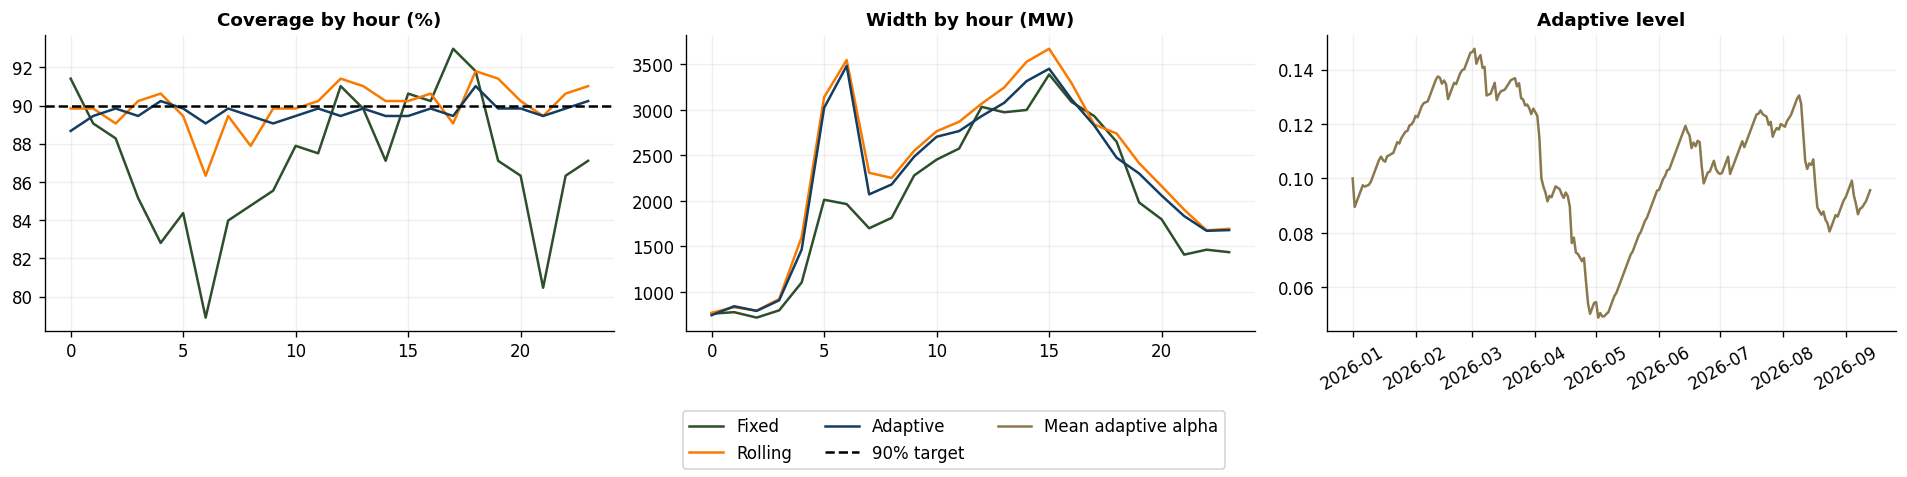

Adaptive levels at a bound (%): 0.6


In [33]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4), dpi=120)
for k, method in enumerate(["Fixed", "Rolling", "Adaptive"]):
    part = hourly[(hourly.model == "Compact MLP") & (hourly.method == method)]
    axes[0].plot(part.hour, part.coverage_percent, label=method, color=COLORS[k])
    axes[1].plot(part.hour, part.width_MW, label=method, color=COLORS[k])
levels = results[("Compact MLP", "Adaptive")]["alpha"]
axes[2].plot(test_dates, levels.mean(axis=1), label="Mean adaptive alpha", color=COLORS[3])
axes[0].axhline(90, color="black", linestyle="--", label="90% target")
for ax, title in zip(axes, ["Coverage by hour (%)", "Width by hour (MW)", "Adaptive level"]):
    ax.set_title(title)
axes[2].tick_params(axis="x", rotation=30)
finish(fig, "06_hourly_calibration")
print("Adaptive levels at a bound (%):", round(100 * ((levels <= 0.04) | (levels >= 0.30)).mean(), 2))

### Paired uncertainty on the interval-score difference
A seven-day moving-block bootstrap preserves short-range dependence within sampled blocks. Negative differences mean adaptive calibration has a lower interval score than the comparator. These approximate 95% intervals are descriptive, conditional on this fitted model and this test period; they do not prove superiority under arbitrary drift. The block length is fixed in advance.

In [34]:
def daily_interval_score(out):
    lower, upper = out["lower"], out["upper"]
    score = upper - lower + 2 / ALPHA * (np.maximum(lower - ty, 0) + np.maximum(ty - upper, 0))
    return score.mean(axis=1)

def block_ci(delta, block=7, repeats=1000):
    rng = np.random.default_rng(SEED)
    n = len(delta)
    means = []
    for _ in range(repeats):
        starts = rng.integers(0, n - block + 1, size=int(np.ceil(n / block)))
        ids = (starts[:, None] + np.arange(block)).ravel()[:n]
        means.append(delta[ids].mean())
    return np.quantile(means, [0.025, 0.975])

Use identical test days for both methods in each paired comparison.

In [35]:
comparisons = []
for name in pred:
    adaptive = daily_interval_score(results[(name, "Adaptive")])
    for method in ["Fixed", "Rolling"]:
        delta = adaptive - daily_interval_score(results[(name, method)])
        low, high = block_ci(delta)
        comparisons.append({"model": name, "comparison": f"Adaptive minus {method}",
            "mean score difference": delta.mean(), "95% lower": low, "95% upper": high})
comparison_table = pd.DataFrame(comparisons)
display(comparison_table.round(2))

,model,comparison,mean score difference,95% lower,95% upper
0,Seasonal naive,Adaptive minus Fixed,-75.28,-820.04,578.86
1,Seasonal naive,Adaptive minus Rolling,100.42,-47.51,233.08
2,Boosted trees,Adaptive minus Fixed,-77.43,-531.30,402.52
3,Boosted trees,Adaptive minus Rolling,29.50,-44.19,94.32
4,Compact MLP,Adaptive minus Fixed,45.57,-102.12,173.45
5,Compact MLP,Adaptive minus Rolling,-21.32,-100.44,74.89


### Generate the next unobserved day's forecast
This application example predicts the day after the final observed day. It is **not evaluated**, because its actual demand is absent from this file. The error-feedback state is advanced once using the final observed test day.

In [36]:
next_day = series.index[-1].normalize() + pd.Timedelta(days=1)
past = series.reindex(pd.date_range(next_day - pd.Timedelta(hours=168), periods=168, freq="h")).to_numpy()
assert np.isfinite(past).all(), "Next-day forecast requires a complete past week"
next_x = np.r_[past, calendar_features(next_day)].astype(np.float32)[None, :]
next_p = neural_predict(xs.transform(next_x).astype(np.float32), past[:24][None, :])[0]
config = settings[("Compact MLP", "Adaptive")]
last_out = results[("Compact MLP", "Adaptive")]
last_error = np.abs(ty[-1] - pred["Compact MLP"]["test"][-1])
last_radius = (last_out["upper"][-1] - last_out["lower"][-1]) / 2
next_level = np.clip(last_out["alpha"][-1] + config["gamma"] * (ALPHA - (last_error > last_radius)), 0.04, 0.30)

The latest observed errors provide the new interval radius. The output contains 24 forecasts in MW, with lower and upper bounds.

In [37]:
errors = np.vstack([np.abs(Y[idx["cal"]] - pred["Compact MLP"]["cal"]),
                    np.abs(ty - pred["Compact MLP"]["test"])])
next_q = conformal_radius(errors[-config["window"]:], next_level)
next_forecast = pd.DataFrame({"date": pd.date_range(next_day, periods=24, freq="h"),
    "forecast_MW": next_p, "lower_90_MW": next_p - next_q, "upper_90_MW": next_p + next_q})
display(next_forecast.round(2))

,date,forecast_MW,lower_90_MW,upper_90_MW
0,2026-09-14 00:00:00,18409.19,17811.69,19006.70
1,2026-09-14 01:00:00,18092.45,17625.98,18558.91
2,2026-09-14 02:00:00,17738.16,17294.94,18181.39
3,2026-09-14 03:00:00,18140.53,17563.95,18717.11
4,2026-09-14 04:00:00,19969.90,19229.98,20709.83
5,2026-09-14 05:00:00,22907.74,21426.19,24389.29
6,2026-09-14 06:00:00,24695.40,22878.52,26512.28
7,2026-09-14 07:00:00,23265.72,22180.97,24350.47
8,2026-09-14 08:00:00,22893.52,21892.31,23894.74
9,2026-09-14 09:00:00,22867.46,21525.47,24209.44


#### Save results and model
These exports preserve full-precision results, the split, tuning decisions, source-file fingerprint and package versions. They allow later writing to quote measured results rather than expected improvements.

In [38]:
tables = {
    "summary": summary_table, "validation_tuning": tuning_table,
    "splits": split_table, "test_forecasts": forecasts, "monthly_metrics": monthly,
    "hourly_metrics": hourly, "paired_score_comparisons": comparison_table,
    "next_day_forecast": next_forecast
}
for name, table in tables.items():
    table.to_csv(OUT / f"{name}.csv", index=False)
audit.to_csv(OUT / "data_audit.csv", header=["value"])
torch.save({"state_dict": {k: v.cpu() for k, v in model.state_dict().items()},
    "n_features": X.shape[1]}, OUT / "compact_mlp.pt")
joblib.dump({"x_scaler": xs, "residual_scaler": ys, "tree": tree}, OUT / "preprocessing_and_tree.joblib")
np.savez(OUT / "adaptive_state.npz", recent_errors=errors[-config["window"]:],
         next_alpha=next_level, last_observed=str(series.index[-1]))

Save the exact run configuration and environment. Model loading later requires the `DemandNet` definition above and the saved scalers.

In [39]:
versions = {
    p: importlib.metadata.version(p) for p in ["numpy", "pandas", "matplotlib", "scikit-learn", "torch", "pigmenta", "joblib"]
}
manifest = {
    "seed": SEED, "target": TARGET, "units": "MW", "nominal_coverage": 1 - ALPHA,
    "lookback_hours": LOOKBACK, "horizon_hours": HORIZON,
    "split_boundaries": [TRAIN_END, VALID_END, CAL_END], "epochs_run": len(history),
    "device": str(device), "versions": versions,
    "calibration_settings": {f"{k[0]} / {k[1]}": v for k, v in settings.items()},
    "source_sha256": hashlib.sha256(DATA_PATH.read_bytes()).hexdigest(),
    "last_actual": str(last), "point_model_refitting": False}
(OUT / "run_manifest.json").write_text(json.dumps(manifest, indent=2))
print("Saved results to:", OUT.resolve())

Saved results to: C:\Users\crisp\Documents\PENDING PROJECTS\ZendTo-eMffXpBB7uc5m8Wj\electricity_results


### Read the findings honestly
The next cell prints the measured neural results. An adaptive method may help, make intervals unnecessarily wide, or fail during some periods. A result that rolling calibration performs just as well is scientifically useful.

In [40]:
neural_summary = summary_table[summary_table.Model == "Compact MLP"]
for _, row in neural_summary.iterrows():
    print(f"{row['Calibration']}: MAE {row['MAE (MW)']:.1f} MW; "
          f"coverage {row['Coverage (%)']:.2f}%; width {row['Width (MW)']:.1f} MW; "
          f"interval score {row['Interval score']:.1f}.")
print(f"Test: {test_dates[0]:%Y-%m-%d} to {test_dates[-1]:%Y-%m-%d} ({len(test_dates)} days).")

Fixed: MAE 526.0 MW; coverage 87.11%; width 2005.1 MW; interval score 3129.3.
Rolling: MAE 526.0 MW; coverage 89.99%; width 2358.5 MW; interval score 3196.2.
Adaptive: MAE 526.0 MW; coverage 89.66%; width 2259.0 MW; interval score 3174.9.
Test: 2026-01-01 to 2026-09-13 (256 days).


## References and implementation sources
1. Eskom. (n.d.). [Demand side: Data Portal](https://www.eskom.co.za/dataportal/demand-side/). Source context for hourly actual and forecast demand. The portal notes that metering values remain subject to verification.
2. Gibbs, I., & Candès, E. (2021). [Adaptive conformal inference under distribution shift](https://arxiv.org/abs/2106.00170). *Advances in Neural Information Processing Systems*. Basis for error-feedback adaptation; our clipped implementation is a practical variant.
3. Zaffran, M., Dieuleveut, A., Féron, O., Goude, Y., & Josse, J. (2022). [Adaptive conformal predictions for time series](https://arxiv.org/abs/2202.07282). *Proceedings of the 39th International Conference on Machine Learning*. Relevant time-series and day-ahead forecasting context.
4. Gibbs, I., & Candès, E. (2024). [Conformal inference for online prediction with arbitrary distribution shifts](https://arxiv.org/abs/2208.08401). *Journal of Machine Learning Research, 25*. Further adaptive calibration development; not implemented here.
5. PyTorch contributors. (n.d.). [Linear layers](https://docs.pytorch.org/docs/stable/generated/torch.nn.Linear.html). Implementation reference.
6. scikit-learn developers. (n.d.). [HistGradientBoostingRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingRegressor.html). Implementation reference.
7. Gari, C. (2025). [Pigmenta (version 0.0.2)](https://pypi.org/project/pigmenta/). Consistent Nature palette.